In [1]:
%env CUBLAS_WORKSPACE_CONFIG=:4096:8

import pandas as pd
import numpy as np
import pickle
from rdkit import Chem
import torch
from torch_geometric.data import InMemoryDataset
import pandas as pd
from networks import GAT, PPGAT
from sklearn.metrics import accuracy_score, roc_auc_score
from torch_geometric.data import DataLoader
import random
import pickle
from scipy.stats import wilcoxon
import json
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from reduceGraph import mol_to_graph, graph_to_pyg, reduce_graph_from_mol, mol_to_pool_idx, graph_to_pyg_oh, reduce_graph_from_mol_oh
    

env: CUBLAS_WORKSPACE_CONFIG=:4096:8


In [2]:
#set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(mode=True)

In [3]:
def analogue_series_split(data, seed=42, test_size=0.3, n_splits=10, n_cpds_tolerance=5):
    
    from collections import defaultdict

    scaffolds = defaultdict(list)
    for idx, core in enumerate(data.core):
        scaffolds[core].append(idx)
    
    n_total_test = int(np.floor(test_size * len(data)))
    rng = np.random.RandomState(seed)
    for i in range(n_splits):

        scaffold_list = list(scaffolds.values())
        scaffold_indices = rng.permutation(len(scaffold_list))
        scaffold_sets = [scaffold_list[i] for i in scaffold_indices]

        train_index = []
        test_index = []

        for scaffold_set in scaffold_sets:
            if len(test_index) + len(scaffold_set) <= n_total_test:
                test_index.extend(scaffold_set)
            else:
                train_index.extend(scaffold_set)
        
        # Check for tolerance requirement
        if np.abs(len(test_index) - n_total_test) <= n_cpds_tolerance:
            print(f"Split {i} meets tolerance.")
            print(f"Train proportion: {len(train_index)/len(data):.2f}")
            print(f"Test proportion: {len(test_index)/len(data):.2f}")
            yield train_index, test_index
        else:
            print(f"Warning: Split {i} does not meet tolerance. Test size: {len(test_index)}, Expected: {n_total_test}")
            yield train_index, test_index

In [4]:
with open('datasets/df_random_vs_st_dataset_revised.pkl', 'rb') as f:
    data = pickle.load(f)

targets = data['accession'].unique()

In [5]:

def smiles_to_data(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  
    graph = mol_to_graph(mol)   # mol to networkx 
    data = graph_to_pyg_oh(graph)  # networx graph to pytorch geometric graph
    data.y = torch.tensor([label], dtype=torch.float) #add label 
    return data

def dataframe_to_pyg_dataset(df, smiles_col='nonstereo_aromatic_smiles', label_col='label'):
    data_list = []

    for idx, row in df.iterrows():
        smiles = row[smiles_col]
        label = row[label_col]
        data = smiles_to_data(smiles, label)
        if data is not None:
            data.smiles = smiles
            data_list.append(data)

    return data_list

def smiles_to_rgdata(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  
    data = reduce_graph_from_mol_oh(mol)  # pytorch geometric RG graph from mol 
    data.y = torch.tensor([label], dtype=torch.float) #add label 
    return data
def dataframe_to_rg_pyg_dataset(df, smiles_col='nonstereo_aromatic_smiles', label_col='label'):
    data_list = []

    for idx, row in df.iterrows():
        smiles = row[smiles_col]
        label = row[label_col]
        data = smiles_to_rgdata(smiles, label)
        if data is not None:
            #add smiles to dataset 
            data.smiles = smiles            
            data_list.append(data)

    return data_list

def smiles_to_ppgat_data(smiles, label):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None  
    G = mol_to_graph(mol)   # mol to networkx 
    data = graph_to_pyg_oh(G)  # networx graph to pytorch geometric graph
    data.y = torch.tensor([label], dtype=torch.float) #add label 
    pharma_index, new_edge_index, new_edge_attr = mol_to_pool_idx(mol)
    data.pharma_index = pharma_index
    data.new_edge_index = new_edge_index
    data.new_edge_attr = new_edge_attr
    return data

def dataframe_to_ppgat_pyg_dataset(df, smiles_col='nonstereo_aromatic_smiles', label_col='label'):
    data_list = []

    for idx, row in df.iterrows():
        smiles = row[smiles_col]
        label = row[label_col]
        data = smiles_to_ppgat_data(smiles, label)
        if data is not None:
            data.smiles = smiles
            data_list.append(data)

    return data_list

def evaluate_model(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            out = model(data)
            probs = torch.sigmoid(out).view(-1).cpu().numpy()
            labels = data.y.view(-1).cpu().numpy()

            # Ensure probs and labels are arrays, even for batch size 1
            probs = np.atleast_1d(probs)
            labels = np.atleast_1d(labels)

            all_probs.extend(probs)
            all_labels.extend(labels)

    y_pred = (np.array(all_probs) > 0.5).astype(int)
    acc = accuracy_score(all_labels, y_pred)
    auroc = roc_auc_score(all_labels, all_probs)
    return acc, auroc

def subset_by_smiles(dataset, smiles_subset):
    smiles_set = set(smiles_subset)
    return [data for data in dataset if data.smiles in smiles_set]

In [6]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            out = model(data)
            probs = torch.sigmoid(out).view(-1).cpu().numpy()
            labels = data.y.view(-1).cpu().numpy()

            # Ensure probs and labels are arrays, even for batch size 1
            probs = np.atleast_1d(probs)
            labels = np.atleast_1d(labels)

            all_probs.extend(probs)
            all_labels.extend(labels)

    y_pred = (np.array(all_probs) > 0.5).astype(int)
    acc = accuracy_score(all_labels, y_pred)
    auroc = roc_auc_score(all_labels, all_probs)
    return acc, auroc

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
with open('datasets/df_random_vs_st_dataset_revised.pkl', 'rb') as f:
    all_data = pickle.load(f)

In [9]:
#Analogueseriessplitor all targets for 5 runs

In [10]:

GAT_acc_runs = {}
GAT_rg_acc_runs = {}
PPGAT_acc_runs = {}

GAT_auroc_runs = {}
GAT_rg_auroc_runs = {}
PPGAT_auroc_runs = {}

trials = 5

for target in targets:
    print("TARGET:", target)

    df_data = pd.read_csv(f"analogue_series_split/df_ccr_results_{target}.csv")

    #
    # CREATE SPLITS 
    df_train_all_splits = pd.DataFrame()
    df_test_all_splits = pd.DataFrame()

    for trial, (train_index, test_index) in enumerate(
        analogue_series_split(df_data, seed=42, test_size=0.2, n_splits=trials)
    ):
        df_train = df_data.iloc[train_index].copy()
        df_test  = df_data.iloc[test_index].copy()

        df_train["trial"] = trial
        df_test["trial"]  = trial

        df_train_all_splits = pd.concat([df_train_all_splits, df_train])
        df_test_all_splits  = pd.concat([df_test_all_splits, df_test])

    # STORE SCORES
    acc_scores = []
    auroc_scores = []

    acc_scores_rg = []
    auroc_scores_rg= []

    acc_scores_ppgat = []
    auroc_scores_ppgat = []

    #inactive data

    filtered_data = all_data[all_data['accession'] == target]


    # MAIN RUN LOOP 
    for run in range(trials):
        print("RUN:", run)

        train_val_set = df_train_all_splits[df_train_all_splits['trial'] == run] 
        test_set = df_test_all_splits[df_test_all_splits['trial'] == run].copy()

        # get val split
        train_set = pd.DataFrame()
        val_set= pd.DataFrame()

        for trial, (train_index, val_index) in enumerate(
            analogue_series_split(train_val_set, seed=42, test_size=0.1, n_splits=1)
        ):
            df_train = train_val_set.iloc[train_index].copy()
            df_val   = train_val_set.iloc[val_index].copy()

            train_set = pd.concat([train_set, df_train])
            val_set   = pd.concat([val_set, df_val])

        # labels
        test_set["label"] = 1
        train_set["label"] = 1
        val_set["label"] = 1

        # inactive data
        
        inactive_data = filtered_data[filtered_data['label'] == 0].copy()

        inactive_data = inactive_data.rename(columns={
            "chembl_cid": "cid",
            "chembl_tid": "tid",
            "nonstereo_aromatic_smiles": "smiles"
        })

        n_train_active = len(train_set)
        n_test_active  = len(test_set)
        n_val_active   = len(val_set)

        total_needed = n_train_active + n_test_active + n_val_active

        inactive_sample = inactive_data.sample(
            n=total_needed,
            replace=False,
            random_state= 42 + run
        )

        inactive_train = inactive_sample.iloc[:n_train_active]
        inactive_test  = inactive_sample.iloc[n_train_active : n_train_active + n_test_active]
        inactive_val   = inactive_sample.iloc[n_train_active + n_test_active:]

        train_balanced = pd.concat([train_set, inactive_train]).reset_index(drop=True)
        test_balanced  = pd.concat([test_set, inactive_test]).reset_index(drop=True)
        val_balanced   = pd.concat([val_set, inactive_val]).reset_index(drop=True)

        # datasets

        dataset = torch.load(f'datasets/Gdatasets/{target}_dataset.pt', weights_only=False)
        rg_dataset = torch.load(f'datasets/RGdatasets/{target}_RG_dataset.pt', weights_only=False)
        ppgat_dataset = torch.load(f'datasets/PPGATdatasets/{target}_PPGAT_dataset.pt', weights_only=False)


        test_set = subset_by_smiles(dataset, test_balanced.smiles)
        train_set = subset_by_smiles(dataset, train_balanced.smiles)
        val_set = subset_by_smiles(dataset, val_balanced.smiles)

        test_rg = subset_by_smiles(rg_dataset, test_balanced.smiles)
        train_rg = subset_by_smiles(rg_dataset, train_balanced.smiles)
        val_rg = subset_by_smiles(rg_dataset, val_balanced.smiles)

        test_ppgat = subset_by_smiles(ppgat_dataset, test_balanced.smiles)
        train_ppgat = subset_by_smiles(ppgat_dataset, train_balanced.smiles)
        val_ppgat = subset_by_smiles(ppgat_dataset, val_balanced.smiles)

  

        # GAT
        print("GAT")


        #get best configurations:

        with open(f"results/models/gat/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        train_loader = DataLoader(train_set, batch_size=batch_size)
        test_loader  = DataLoader(test_set, batch_size=batch_size)
        val_loader   = DataLoader(val_set, batch_size=batch_size)

        model = GAT(
            in_channels=train_set[0].x.shape[1],
            edge_attr_dim=train_set[0].edge_attr.shape[1] if train_set[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.BCEWithLogitsLoss()

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores.append(final_acc)
        auroc_scores.append(final_auroc)

        # GAT-rg
        print("GAT-rg")

        #get best configurations:

        with open(f"results/models/gat_rg/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        train_loader = DataLoader(train_rg, batch_size=batch_size)
        test_loader  = DataLoader(test_rg, batch_size=batch_size)

        model = GAT(
            in_channels=train_rg[0].x.shape[1],
            edge_attr_dim=train_rg[0].edge_attr.shape[1] if train_rg[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores_rg.append(final_acc)
        auroc_scores_rg.append(final_auroc)

        # PPGAT
        print("PPGAT")

        #get best configuration 
        with open(f"results/models/ppgat/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        train_loader = DataLoader(train_ppgat, batch_size=batch_size)
        test_loader  = DataLoader(test_ppgat, batch_size=batch_size)

        model = PPGAT(
            in_channels=train_ppgat[0].x.shape[1],
            edge_attr_dim=train_ppgat[0].edge_attr.shape[1] if train_ppgat[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores_ppgat.append(final_acc)
        auroc_scores_ppgat.append(final_auroc)


    # STORE ALL RUNS PER TARGET (for stat test)
    GAT_acc_runs[target] = acc_scores
    GAT_auroc_runs[target] = auroc_scores

    GAT_rg_acc_runs[target] = acc_scores_rg
    GAT_rg_auroc_runs[target] = auroc_scores_rg

    PPGAT_acc_runs[target] = acc_scores_ppgat
    PPGAT_auroc_runs[target] = auroc_scores_ppgat

#save file
rows = []

for target in targets:
    for run in range(trials):
        rows.append({
            "target": target,
            "run": run,

            "GAT_acc": GAT_acc_runs[target][run],
            "GAT_auroc": GAT_auroc_runs[target][run],

            "GAT_rg_acc": GAT_rg_acc_runs[target][run],
            "GAT_rg_auroc": GAT_rg_auroc_runs[target][run],

            "PPGAT_acc": PPGAT_acc_runs[target][run],
            "PPGAT_auroc": PPGAT_auroc_runs[target][run],
        })

runs_df = pd.DataFrame(rows)

runs_df.to_csv("analogue_series_runs.csv", index=False)


# FINAL TABLE
results = []

for target in targets:
    results.append({
        "target": target,

        "GAT_acc_mean": np.mean(GAT_acc_runs[target]),
        "GAT_acc_std":  np.std(GAT_acc_runs[target]),
        "GAT_auroc_mean": np.mean(GAT_auroc_runs[target]),
        "GAT_auroc_std":  np.std(GAT_auroc_runs[target]),

        "GAT_rg_acc_mean": np.mean(GAT_rg_acc_runs[target]),
        "GAT_rg_acc_std":  np.std(GAT_rg_acc_runs[target]),
        "GAT_rg_auroc_mean": np.mean(GAT_rg_auroc_runs[target]),
        "GAT_rg_auroc_std":  np.std(GAT_rg_auroc_runs[target]),

        "PPGAT_acc_mean": np.mean(PPGAT_acc_runs[target]),
        "PPGAT_acc_std":  np.std(PPGAT_acc_runs[target]),
        "PPGAT_auroc_mean": np.mean(PPGAT_auroc_runs[target]),
        "PPGAT_auroc_std":  np.std(PPGAT_auroc_runs[target]),
    })

results_df = pd.DataFrame(results)
print(results_df)



TARGET: P08581
Split 0 meets tolerance.
Train proportion: 0.80
Test proportion: 0.20
Split 1 meets tolerance.
Train proportion: 0.80
Test proportion: 0.20
Split 2 meets tolerance.
Train proportion: 0.80
Test proportion: 0.20
Split 3 meets tolerance.
Train proportion: 0.80
Test proportion: 0.20
Split 4 meets tolerance.
Train proportion: 0.80
Test proportion: 0.20
RUN: 0
Split 0 meets tolerance.
Train proportion: 0.90
Test proportion: 0.10
GAT


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


GAT-rg


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


PPGAT


...

GAT-rg


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


PPGAT


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


   target  GAT_acc_mean  GAT_acc_std  GAT_auroc_mean  GAT_auroc_std  \
0  P08581      0.801032     0.032454        0.912322       0.008824   
1  P35968      0.743827     0.034160        0.837521       0.027424   
2  Q16790      0.887447     0.017021        0.948791       0.009717   
3  P56817      0.843822     0.018992        0.912825       0.027539   
4  P22303      0.771556     0.036688        0.866054       0.028710   
5  P06276      0.800873     0.014645        0.907544       0.012364   
6  P00915      0.935598     0.017158        0.981277       0.006314   
7  P34913      0.849631     0.034611        0.947679       0.016529   
8  Q13547      0.808829     0.081409        0.874207       0.085356   
9  P27487      0.930506     0.007459        0.965164       0.008877   

   GAT_rg_acc_mean  GAT_rg_acc_std  GAT_rg_auroc_mean  GAT_rg_auroc_std  \
0         0.743912        0.077123           0.819723          0.065517   
1         0.599074        0.073883           0.751879          0.061

In [11]:
results_df

,target,GAT_acc_mean,GAT_acc_std,GAT_auroc_mean,GAT_auroc_std,GAT_rg_acc_mean,GAT_rg_acc_std,GAT_rg_auroc_mean,GAT_rg_auroc_std,PPGAT_acc_mean,PPGAT_acc_std,PPGAT_auroc_mean,PPGAT_auroc_std
0,P08581,0.801032,0.032454,0.912322,0.008824,0.743912,0.077123,0.819723,0.065517,0.798221,0.027844,0.886018,0.015034
1,P35968,0.743827,0.034160,0.837521,0.027424,0.599074,0.073883,0.751879,0.061838,0.683025,0.073048,0.828294,0.034704
2,Q16790,0.887447,0.017021,0.948791,0.009717,0.890902,0.023020,0.946368,0.017287,0.847535,0.046182,0.947115,0.012810
3,P56817,0.843822,0.018992,0.912825,0.027539,0.798905,0.043038,0.868382,0.032650,0.879960,0.035722,0.943752,0.025567
4,P22303,0.771556,0.036688,0.866054,0.028710,0.688000,0.076782,0.805884,0.045783,0.723556,0.058400,0.846331,0.035096
5,P06276,0.800873,0.014645,0.907544,0.012364,0.711855,0.057821,0.804869,0.021803,0.779569,0.031251,0.881390,0.043380
6,P00915,0.935598,0.017158,0.981277,0.006314,0.931808,0.012861,0.969815,0.008583,0.918703,0.032255,0.971176,0.008992
7,P34913,0.849631,0.034611,0.947679,0.016529,0.845356,0.039838,0.925745,0.032316,0.807390,0.021494,0.914995,0.014128
8,Q13547,0.808829,0.081409,0.874207,0.085356,0.665959,0.083056,0.872944,0.018016,0.854720,0.060273,0.964780,0.014775
9,P27487,0.930506,0.007459,0.965164,0.008877,0.911913,0.026031,0.958775,0.004797,0.888759,0.019649,0.957028,0.008251


In [12]:
results_df.to_csv("results_analogue_series_split.csv", index=False)

In [13]:
#For random splits 
#for statistical test: STORE ALL RUN RESULTS 
GAT_acc_runs_random = {}
GAT_rg_acc_runs_random = {}
PPGAT_acc_runs_random = {}

GAT_auroc_runs_random = {}
GAT_rg_auroc_runs_random = {}
PPGAT_auroc_runs_random = {}


trials = 5

for target in targets:
    print("TARGET:", target)

    dataset = torch.load(f'datasets/Gdatasets/{target}_dataset.pt', weights_only=False)
    rg_dataset = torch.load(f'datasets/RGdatasets/{target}_RG_dataset.pt', weights_only=False)
    ppgat_dataset = torch.load(f'datasets/PPGATdatasets/{target}_PPGAT_dataset.pt', weights_only=False)


    acc_scores = []
    auroc_scores = []

    acc_scores_rg = []
    auroc_scores_rg= []

    acc_scores_ppgat = []
    auroc_scores_ppgat = []


    for run in range(trials):
        print("RUN:", run)
            
        n = len(dataset)
        indices = np.arange(n)

        #independent run
        np.random.seed(42 + run) 
        np.random.shuffle(indices)

        split_80 = int(0.8 * n)
        train_val_idx = indices[:split_80]
        test_idx = indices[split_80:]
        split_90 = int(0.9 * len(train_val_idx))
        train_idx = train_val_idx[:split_90]
        val_idx = train_val_idx[split_90:]


        # GAT 
        train_set = [dataset[i] for i in train_idx]
        val_set   = [dataset[i] for i in val_idx]
        test_set  = [dataset[i] for i in test_idx]

        # RG 
        train_rg = [rg_dataset[i] for i in train_idx]
        val_rg   = [rg_dataset[i] for i in val_idx]
        test_rg  = [rg_dataset[i] for i in test_idx]

        # PPGAT 
        train_ppgat = [ppgat_dataset[i] for i in train_idx]
        val_ppgat   = [ppgat_dataset[i] for i in val_idx]
        test_ppgat  = [ppgat_dataset[i] for i in test_idx]

        # GAT
        print("GAT")
        
        #get best configuration 
        with open(f"results/models/gat/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        
        train_loader = DataLoader(train_set, batch_size=batch_size)
        test_loader  = DataLoader(test_set, batch_size=batch_size)
        val_loader   = DataLoader(val_set, batch_size=batch_size)

        model = GAT(
            in_channels=train_set[0].x.shape[1],
            edge_attr_dim=train_set[0].edge_attr.shape[1] if train_set[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.BCEWithLogitsLoss()

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores.append(final_acc)
        auroc_scores.append(final_auroc)

        # GAT-rg
        print("GAT-rg")

        #get best configuration 
        with open(f"results/models/gat_rg/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        train_loader = DataLoader(train_rg, batch_size=batch_size)
        test_loader  = DataLoader(test_rg, batch_size=batch_size)

        model = GAT(
            in_channels=train_rg[0].x.shape[1],
            edge_attr_dim=train_rg[0].edge_attr.shape[1] if train_rg[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores_rg.append(final_acc)
        auroc_scores_rg.append(final_auroc)

        # PPGAT
        print("PPGAT")

        #get best configuration 
        with open(f"results/models/ppgat/{target}/best_config.json", "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]

        train_loader = DataLoader(train_ppgat, batch_size=batch_size)
        test_loader  = DataLoader(test_ppgat, batch_size=batch_size)

        model = PPGAT(
            in_channels=train_ppgat[0].x.shape[1],
            edge_attr_dim=train_ppgat[0].edge_attr.shape[1] if train_ppgat[0].edge_attr is not None else 0,
            hidden_channels=64,
            out_channels=1,
            heads=4
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        for epoch in range(1, 101):
            model.train()
            for data in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                loss = criterion(model(data).view(-1), data.y.float())
                loss.backward()
                optimizer.step()

        final_acc, final_auroc = evaluate_model(model, test_loader, device)
        acc_scores_ppgat.append(final_acc)
        auroc_scores_ppgat.append(final_auroc)


    # Store runs (for stat test)
    GAT_acc_runs_random[target] = acc_scores
    GAT_auroc_runs_random[target] = auroc_scores

    GAT_rg_acc_runs_random[target] = acc_scores_rg
    GAT_rg_auroc_runs_random[target] = auroc_scores_rg

    PPGAT_acc_runs_random[target] = acc_scores_ppgat
    PPGAT_auroc_runs_random[target] = auroc_scores_ppgat

#SAVE
rows = []

for target in targets:
    for run in range(trials):
        rows.append({
            "target": target,
            "run": run,

            "GAT_acc": GAT_acc_runs_random[target][run],
            "GAT_auroc": GAT_auroc_runs_random[target][run],

            "GAT_rg_acc": GAT_rg_acc_runs_random[target][run],
            "GAT_rg_auroc": GAT_rg_auroc_runs_random[target][run],

            "PPGAT_acc": PPGAT_acc_runs_random[target][run],
            "PPGAT_auroc": PPGAT_auroc_runs_random[target][run],
        })

runs_df = pd.DataFrame(rows)

runs_df.to_csv("random_split_runs.csv", index=False)

# FINAL TABLE
results = []

for target in targets:
    results.append({
        "target": target,

        "GAT_acc_mean": np.mean(GAT_acc_runs_random[target]),
        "GAT_acc_std":  np.std(GAT_acc_runs_random[target]),
        "GAT_auroc_mean": np.mean(GAT_auroc_runs_random[target]),
        "GAT_auroc_std":  np.std(GAT_auroc_runs_random[target]),

        "GAT_rg_acc_mean": np.mean(GAT_rg_acc_runs_random[target]),
        "GAT_rg_acc_std":  np.std(GAT_rg_acc_runs_random[target]),
        "GAT_rg_auroc_mean": np.mean(GAT_rg_auroc_runs_random[target]),
        "GAT_rg_auroc_std":  np.std(GAT_rg_auroc_runs_random[target]),

        "PPGAT_acc_mean": np.mean(PPGAT_acc_runs_random[target]),
        "PPGAT_acc_std":  np.std(PPGAT_acc_runs_random[target]),
        "PPGAT_auroc_mean": np.mean(PPGAT_auroc_runs_random[target]),
        "PPGAT_auroc_std":  np.std(PPGAT_auroc_runs_random[target]),
    })

results_df = pd.DataFrame(results)
print(results_df)


TARGET: P08581
RUN: 0
GAT


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


GAT-rg


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


PPGAT


...

GAT-rg


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


PPGAT


/home/tejaurrutoam1/.conda/envs/pyg_v3/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


   target  GAT_acc_mean  GAT_acc_std  GAT_auroc_mean  GAT_auroc_std  \
0  P08581      0.936749     0.012463        0.979585       0.004099   
1  P35968      0.873069     0.013682        0.936593       0.007134   
2  Q16790      0.967063     0.007499        0.987848       0.003341   
3  P56817      0.917391     0.018029        0.973502       0.007171   
4  P22303      0.908937     0.013719        0.960620       0.009777   
5  P06276      0.904981     0.014569        0.963095       0.005212   
6  P00915      0.965674     0.001359        0.988441       0.001320   
7  P34913      0.946620     0.005738        0.985619       0.003539   
8  Q13547      0.974877     0.002413        0.986447       0.001831   
9  P27487      0.965230     0.007460        0.990187       0.004401   

   GAT_rg_acc_mean  GAT_rg_acc_std  GAT_rg_auroc_mean  GAT_rg_auroc_std  \
0         0.926855        0.007628           0.973671          0.004353   
1         0.872277        0.010270           0.937839          0.004

In [14]:
results_df.to_csv("results_random_splits.csv", index=False)

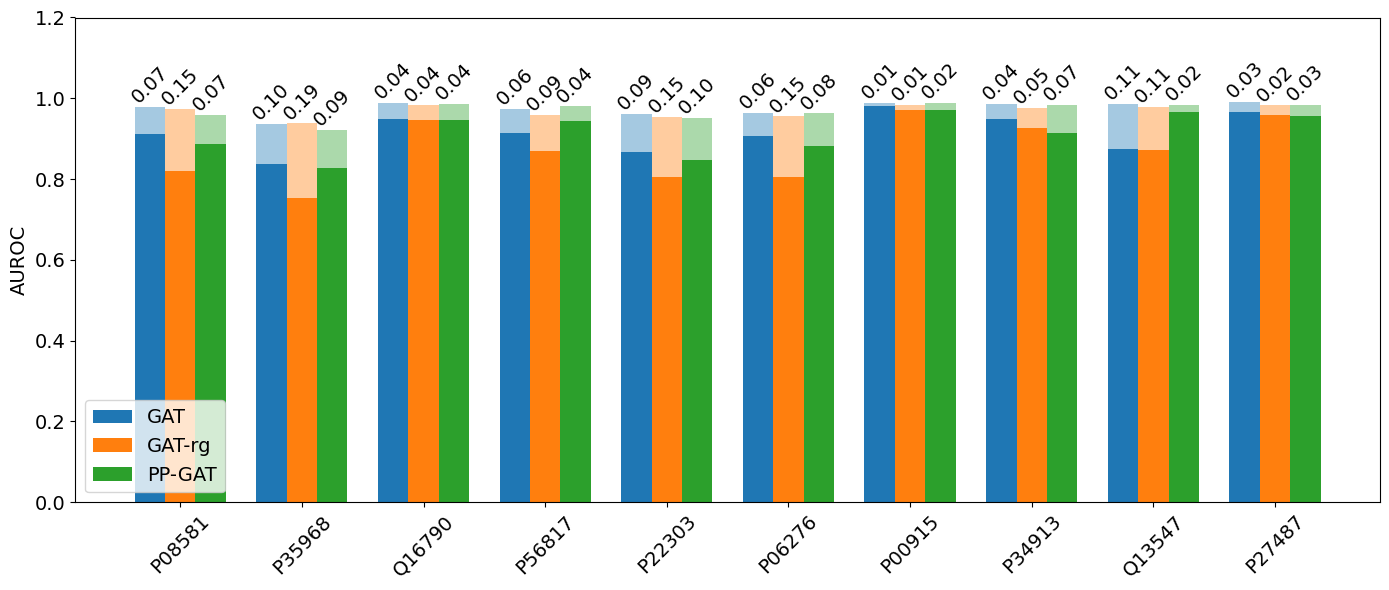

In [15]:


# Load data
df_random = pd.read_csv("results_random_splits.csv")
df_analogue = pd.read_csv("results_analogue_series_split.csv")


targets = df_analogue["target"]
models = ["GAT", "GAT_rg", "PPGAT"]
model_labels = {"GAT":"GAT", "GAT_rg": "GAT-rg", "PPGAT": "PP-GAT"}

x = np.arange(len(targets))
width = 0.25

# Base colors per model
base_colors = {
    "GAT": "tab:blue",
    "GAT_rg": "tab:orange",
    "PPGAT": "tab:green"
}

# lighten color
def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(models):
    rand = df_random[f"{model}_auroc_mean"]
    ana  = df_analogue[f"{model}_auroc_mean"]
    drop = rand - ana

    offset = (i - 1) * width

    base_color = base_colors[model]
    light_color = lighten_color(base_color, 0.6)

    # Analogue (bottom)
    bars_ana = ax.bar(
        x + offset, ana, width,
        color=base_color,
        label= model_labels[model],
    )

    # Drop (top)
    bars_drop = ax.bar(
        x + offset, drop, width,
        bottom=ana,
        color=light_color,
    )

    #  drop values
    for j in range(len(x)):
        ax.text(
            x[j] + offset,
            ana.iloc[j] + drop.iloc[j],  
            f"{drop.iloc[j]:.2f}",
            ha='center',
            va='bottom',
            fontsize=14,
            rotation=45
        )

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(targets, rotation=45, fontsize=14)
ax.set_ylabel("AUROC", fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Legend
ax.set_ylim(0, 1.2)
ax.legend(loc='lower left', fontsize=14)
plt.tight_layout()

plt.savefig("auroc_as_drop.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
df_random = pd.read_csv("results_random_splits.csv")
df_analogue = pd.read_csv("results_analogue_series_split.csv")

df_drop = pd.DataFrame()
df_drop["target"] = df_analogue["target"]

df_r = df_random.set_index("target")
df_a = df_analogue.set_index("target")



df_drop["GAT_drop"] = df_random["GAT_auroc_mean"] - df_analogue["GAT_auroc_mean"]
df_drop["GAT_rg_drop"] = df_random["GAT_rg_auroc_mean"] - df_analogue["GAT_rg_auroc_mean"]
df_drop["PPGAT_drop"] = df_random["PPGAT_auroc_mean"] - df_analogue["PPGAT_auroc_mean"]

avg_drop_GAT = df_drop["GAT_drop"].mean()
avg_drop_GAT_rg = df_drop["GAT_rg_drop"].mean()
avg_drop_PPGAT = df_drop["PPGAT_drop"].mean()


print(df_drop)

print("Average AUROC drop:")
print(f"GAT:     {avg_drop_GAT:.4f}")
print(f"GAT-rg:  {avg_drop_GAT_rg:.4f}")
print(f"PPGAT:   {avg_drop_PPGAT:.4f}")


   target  GAT_drop  GAT_rg_drop  PPGAT_drop
0  P08581  0.067263     0.153948    0.073689
1  P35968  0.099072     0.185961    0.092879
2  Q16790  0.039057     0.035772    0.039452
3  P56817  0.060677     0.089628    0.036016
4  P22303  0.094566     0.147290    0.104420
5  P06276  0.055552     0.150392    0.080958
6  P00915  0.007164     0.014646    0.017194
7  P34913  0.037940     0.049790    0.067738
8  Q13547  0.112240     0.106434    0.017989
9  P27487  0.025023     0.023598    0.026756
Average AUROC drop:
GAT:     0.0599
GAT-rg:  0.0957
PPGAT:   0.0557


In [17]:

p_ppgat_gat = wilcoxon(df_drop["GAT_drop"],df_drop["PPGAT_drop"]).pvalue
p_ppgat_gat_rg = wilcoxon(df_drop["PPGAT_drop"], df_drop["GAT_rg_drop"]).pvalue
gat_gat_rg = wilcoxon(df_drop["GAT_drop"], df_drop["GAT_rg_drop"]).pvalue

print(p_ppgat_gat,p_ppgat_gat_rg,gat_gat_rg)

0.4921875 0.083984375 0.02734375


In [24]:

# Load data
df_rand = pd.read_csv("random_split_runs.csv")
df_ana  = pd.read_csv("analogue_series_runs.csv")

# Merge to align run
df = df_rand.merge(
    df_ana,
    on=["target", "run"],
    suffixes=("_rand", "_ana")
)

# get drops
for model in ["GAT", "GAT_rg", "PPGAT"]:
    df[f"{model}_drop"] = df[f"{model}_auroc_rand"] - df[f"{model}_auroc_ana"]


results = []

for target in df["target"].unique():
    subset = df[df["target"] == target]

    gat = subset["GAT_drop"]
    gat_rg = subset["GAT_rg_drop"]
    ppgat = subset["PPGAT_drop"]

    # Wilcoxon tests 
    p_ppgat_vs_gat = wilcoxon(ppgat, gat).pvalue
    p_gatrg_vs_gat = wilcoxon(gat_rg, gat).pvalue
    p_ppgat_vs_gatrg = wilcoxon(ppgat, gat_rg).pvalue

    results.append({
        "target": target,
        "PPGAT_vs_GAT_p": p_ppgat_vs_gat,
        "GAT_rg_vs_GAT_p": p_gatrg_vs_gat,
        "PPGAT_vs_GAT_rg_p": p_ppgat_vs_gatrg,

    })

results_df = pd.DataFrame(results)

print(results_df)

   target  PPGAT_vs_GAT_p  GAT_rg_vs_GAT_p  PPGAT_vs_GAT_rg_p
0  P08581          0.3125           0.0625             0.0625
1  P35968          0.8125           0.0625             0.0625
2  Q16790          0.8125           0.6250             0.6250
3  P56817          0.1250           0.0625             0.0625
4  P22303          0.8125           0.0625             0.1250
5  P06276          0.4375           0.0625             0.0625
6  P00915          0.1875           0.6250             0.8125
7  P34913          0.1250           0.4375             0.6250
8  Q13547          0.3125           1.0000             0.0625
9  P27487          1.0000           1.0000             0.3125


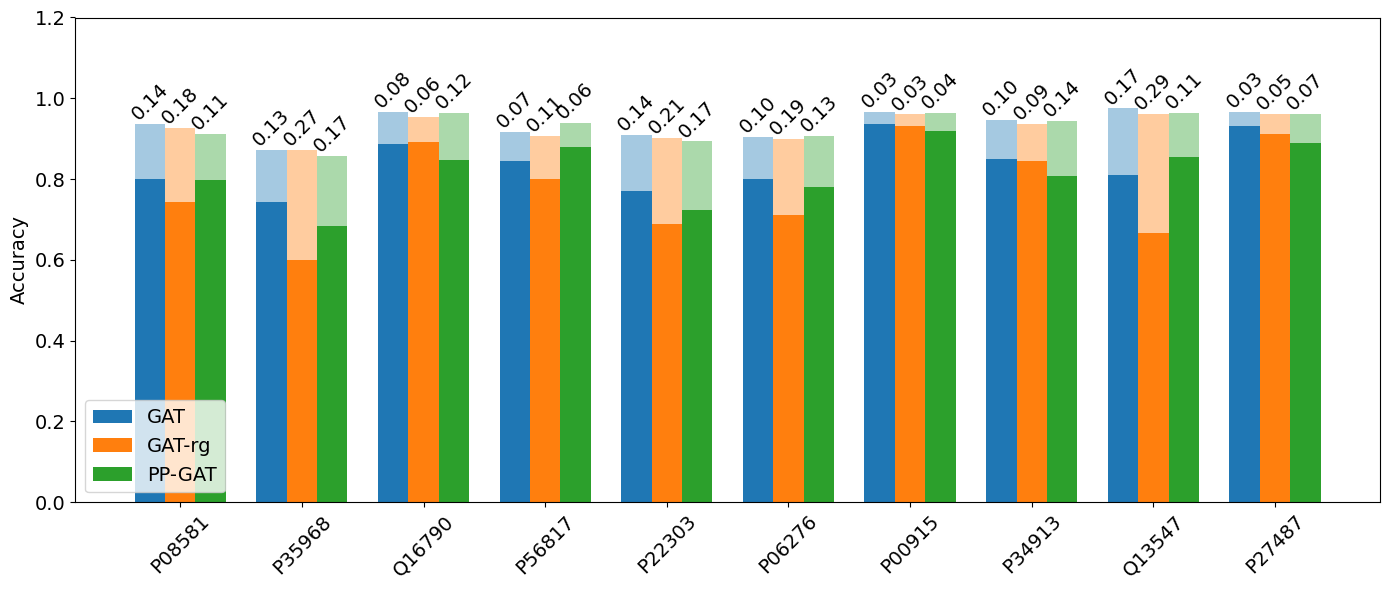

In [19]:
 
# Load data
df_random = pd.read_csv("results_random_splits.csv")
df_analogue = pd.read_csv("results_analogue_series_split.csv")


targets = df_random["target"]
models = ["GAT", "GAT_rg", "PPGAT"]
model_labels = {"GAT":"GAT", "GAT_rg": "GAT-rg", "PPGAT": "PP-GAT"}

x = np.arange(len(targets))
width = 0.25

# Base colors per model
base_colors = {
    "GAT": "tab:blue",
    "GAT_rg": "tab:orange",
    "PPGAT": "tab:green"
}



# Function to lighten color
def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

fig, ax = plt.subplots(figsize=(14, 6))

for i, model in enumerate(models):
    rand = df_random[f"{model}_acc_mean"]
    ana  = df_analogue[f"{model}_acc_mean"]
    drop = rand - ana

    offset = (i - 1) * width

    base_color = base_colors[model]
    light_color = lighten_color(base_color, 0.6)

    # Analogue (bottom)
    bars_ana = ax.bar(
        x + offset, ana, width,
        color=base_color,
        label= model_labels[model]
    )

    # Drop (top)

    drop_label = drop
    drop= np.where(drop < 0, 0, drop)


    bars_drop = ax.bar(
        x + offset, drop, width,
        bottom=ana,
        color=light_color,
    )

    #  drop values
    for j in range(len(x)):
        ax.text(
            x[j] + offset,
            ana.iloc[j] +  drop[j],  
            f"{drop_label[j]:.2f}",
            ha='center',
            va='bottom',
            fontsize=14,
            rotation=45
        )

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(targets, rotation=45, fontsize=14)
ax.set_ylabel("Accuracy", fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Legend
ax.set_ylim(0, 1.2)
ax.legend(loc='lower left', fontsize=14)

plt.tight_layout()

plt.savefig("accuracy_as_drop.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
df_drop = pd.DataFrame()
df_drop["target"] = df_random["target"]

df_drop["GAT_drop"] = df_random["GAT_acc_mean"] - df_analogue["GAT_acc_mean"]
df_drop["GAT_rg_drop"] = df_random["GAT_rg_acc_mean"] - df_analogue["GAT_rg_acc_mean"]
df_drop["PPGAT_drop"] = df_random["PPGAT_acc_mean"] - df_analogue["PPGAT_acc_mean"]

avg_drop_GAT = df_drop["GAT_drop"].mean()
avg_drop_GAT_rg = df_drop["GAT_rg_drop"].mean()
avg_drop_PPGAT = df_drop["PPGAT_drop"].mean()

print("Average accuracy drop:")
print(f"GAT:     {avg_drop_GAT:.4f}")
print(f"GAT-rg:  {avg_drop_GAT_rg:.4f}")
print(f"PPGAT:   {avg_drop_PPGAT:.4f}")

std_drop_GAT = df_drop["GAT_drop"].std()
std_drop_GAT_rg = df_drop["GAT_rg_drop"].std()
std_drop_PPGAT = df_drop["PPGAT_drop"].std()

print("\nStd of accuracy drop:")
print(f"GAT:     {std_drop_GAT:.4f}")
print(f"GAT-rg:  {std_drop_GAT_rg:.4f}")
print(f"PPGAT:   {std_drop_PPGAT:.4f}")

Average accuracy drop:
GAT:     0.0987
GAT-rg:  0.1492
PPGAT:   0.1123

Std of accuracy drop:
GAT:     0.0449
GAT-rg:  0.0946
PPGAT:   0.0434


In [31]:
#WILCOXON TEST 


# Load data
df_rand = pd.read_csv("random_split_runs.csv")
df_ana  = pd.read_csv("analogue_series_runs.csv")

# Merge to align run
df = df_rand.merge(
    df_ana,
    on=["target", "run"],
    suffixes=("_rand", "_ana")
)

# get drops
for model in ["GAT", "GAT_rg", "PPGAT"]:
    df[f"{model}_drop"] = df[f"{model}_acc_rand"] - df[f"{model}_acc_ana"]


results = []

for target in df["target"].unique():
    subset = df[df["target"] == target]

    gat = subset["GAT_drop"]
    gat_rg = subset["GAT_rg_drop"]
    ppgat = subset["PPGAT_drop"]

    # Wilcoxon tests 
    p_ppgat_vs_gat = wilcoxon(ppgat, gat).pvalue
    p_gatrg_vs_gat = wilcoxon(gat_rg, gat).pvalue
    p_ppgat_vs_gatrg = wilcoxon(ppgat, gat_rg).pvalue

    results.append({
        "target": target,
        "PPGAT_vs_GAT_p": p_ppgat_vs_gat,
        "GAT_rg_vs_GAT_p": p_gatrg_vs_gat,
        "PPGAT_vs_GAT_rg_p": p_ppgat_vs_gatrg,

    })

results_df = pd.DataFrame(results)

print(results_df)

   target  PPGAT_vs_GAT_p  GAT_rg_vs_GAT_p  PPGAT_vs_GAT_rg_p
0  P08581          0.4375           0.1875             0.3125
1  P35968          0.6250           0.0625             0.1250
2  Q16790          0.3125           0.4375             0.0625
3  P56817          0.4375           0.3125             0.1875
4  P22303          0.4375           0.1250             0.3125
5  P06276          0.1250           0.0625             0.0625
6  P00915          0.3125           1.0000             0.3125
7  P34913          0.1250           1.0000             0.0625
8  Q13547          0.4375           0.1250             0.0625
9  P27487          0.0625           0.6250             0.1875
